# ============================================================
# NYC Yellow Taxi Analytics — NB1: Data Loading & Cleaning
# Sahil Changotra | April 2026
# ============================================================

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns',None)
pd.set_option('display.float_format',lambda x: '%.2f' % x)

#### Load Data :

In [2]:
df = pd.read_csv('../data/raw/nyc_yellow_taxi_trip_records_from_Jan_to_Aug_2023.csv')

#### Shape and Columns :

In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)

Shape: (19493059, 21)

Columns: ['Unnamed: 0', 'VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'airport_fee']

Data Types:
 Unnamed: 0                 int64
VendorID                   int64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count          float64
trip_distance            float64
RatecodeID               float64
store_and_fwd_flag        object
PULocationID               int64
DOLocationID               int64
payment_type               int64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
cong

In [4]:
df.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,airport_fee
0,0,2,2023-06-30 23:59:59,2023-07-01 00:47:49,2.00,17.62,2.00,N,132,230,1,70.00,0.00,0.50,0.00,6.55,1.00,82.30,2.50,1.75,NaN
1,1,2,2023-06-30 23:59:57,2023-07-01 00:17:36,1.00,3.32,1.00,N,255,198,1,18.40,1.00,0.50,2.50,0.00,1.00,23.40,0.00,0.00,NaN
2,2,1,2023-06-30 23:59:55,2023-07-01 00:14:20,1.00,2.80,1.00,N,231,107,1,14.90,3.50,0.50,3.95,0.00,1.00,23.85,2.50,0.00,NaN
3,3,2,2023-06-30 23:59:55,2023-07-01 00:05:52,1.00,0.89,1.00,N,237,163,1,7.20,1.00,0.50,2.00,0.00,1.00,14.20,2.50,0.00,NaN
4,4,2,2023-06-30 23:59:55,2023-07-01 00:07:08,4.00,1.56,1.00,N,211,90,1,10.00,1.00,0.50,3.00,0.00,1.00,18.00,2.50,0.00,NaN


#### Data Inspection :

In [5]:
# Missing Values
print("===Missing Values===")
missing = df.isnull().sum()
missing_pct = (missing * 100 / len(df)).round(2)
missing_df = pd.DataFrame({'missing_count':missing, 'missing_pct': missing_pct})
print(missing_df[missing_df['missing_count']>0])

===Missing Values===
                      missing_count  missing_pct
passenger_count              528530         2.71
RatecodeID                   528530         2.71
store_and_fwd_flag           528530         2.71
congestion_surcharge         528530         2.71
Airport_fee                 3523475        18.08
airport_fee                16498114        84.64


In [6]:
# Duplicate Rows
print("===Duplicate Rows===")
print(f"Duplicate Rows: {df.duplicated().sum()}")

# Duplicate Columns
print("===Duplicate Columns===")
print("Airport_fee sample :", df['Airport_fee'].describe())
print("airport_fee sample :", df['airport_fee'].describe())

===Duplicate Rows===
Duplicate Rows: 0
===Duplicate Columns===
Airport_fee sample : count   15969584.00
mean           0.13
std            0.44
min           -1.75
25%            0.00
50%            0.00
75%            0.00
max            1.75
Name: Airport_fee, dtype: float64
airport_fee sample : count   2994945.00
mean          0.11
std           0.36
min          -1.25
25%           0.00
50%           0.00
75%           0.00
max           1.25
Name: airport_fee, dtype: float64


#### Data Quality Checks

In [7]:
# Invalid Values

print("=== Data Quality Flags")
print(f"Negative fare amount: {(df['fare_amount'] < 0 ).sum():,}")
print(f"Zero fare amount: {(df['fare_amount']==0).sum():,}")
print(f"Negative trip distance : {(df['trip_distance'] < 0).sum():,}")
print(f"Zero trip distance : {(df['trip_distance']==0).sum():,}")
print(f"Passenger count = 0 : {(df['passenger_count']==0).sum():,}")
print(f"Passenger count > 6 : {(df['passenger_count']==6).sum():,}")
print(f"Passenger count NULL : {(df['passenger_count'].isnull()).sum():,}")
print(f"Ratecode ID 99 : {(df['RatecodeID']==99).sum():,}")
print(f"Negative tip_amount : {(df['tip_amount']<0).sum():,}")
print(f"Negative total amount : {(df['total_amount']<0).sum():,}")

# Timestamp Issues

df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

invalid_timestamps = (df['tpep_dropoff_datetime'] <= df['tpep_pickup_datetime']).sum()
print(f"\nDropoff before or equal to pickup: {invalid_timestamps:,}")

# Date Range Check
print(f"\nDate range : {df['tpep_pickup_datetime'].min()} to {df['tpep_pickup_datetime'].max()}")

# Vendor ID and payment_type values
print(f"\nVendorID unique values: {sorted(df['VendorID'].unique())}")
print(f"payment_type unique values: {sorted(df['payment_type'].unique())}")
print(f"RatecodeID unique_values: {sorted(df['RatecodeID'].dropna().unique())}")


=== Data Quality Flags
Negative fare amount: 173,008
Zero fare amount: 6,766
Negative trip distance : 0
Zero trip distance : 270,072
Passenger count = 0 : 327,708
Passenger count > 6 : 167,549
Passenger count NULL : 528,530
Ratecode ID 99 : 95,155
Negative tip_amount : 1,112
Negative total amount : 172,418

Dropoff before or equal to pickup: 7,434

Date range : 2023-01-01 00:00:00 to 2023-06-30 23:59:59

VendorID unique values: [np.int64(1), np.int64(2), np.int64(6)]
payment_type unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
RatecodeID unique_values: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(99.0)]


#### Full Data Cleaning Pipeline

In [ ]:
print(f"Starting Shape: {df.shape}")
rows_start = len(df)

# Step 1: Drop unnamed index column
df.drop(columns=['Unnamed: 0'], inplace=True)
print(f"After dropping Unnamed: 0 -> {df.shape}")

# Step 2: Merge duplicate airport fee columns
df['airport_fee_clean'] = df['Airport_fee'].fillna(df['airport_fee'])
df.drop(columns=['Airport_fee','airport_fee'],inplace=True)
df.rename(columns={'airport_fee_clean':'airport_fee'}, inplace=True)
print(f"After merging airport fee columns -> {df.shape}")

# Step 3 Cast datetime columns
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
print("Datetime columns cast")

# Step 4: Invalid Rows
before = len(df)

# Negative or Zero fare
df = df[df['fare_amount']> 0]
print(f"After droping fare <= 0 : removed {before - len(df):,} rows")

# Zero trip distance
before = len(df)
df = df[df['trip_distance'] > 0]
print(f"After droping distance = 0: removed {before - len(df):,} rows")

# Invalid Passenger count
before = len(df)
df = df[df['passenger_count'].notna()]
df = df[df['passenger_count'] > 0 & (df['passenger_count'] <= 6)]
print(f"After dropping invalid passenger count: removed {before - len(df):,} rows")

# Negative tip and total
before = len(df)
df = df[(df['tip_amount'] >= 0 ) & (df['total_amount'] > 0)]
print(f"After dropping negative tip/total amount: removed {before - len(df):,} rows")

# Invalid timestamps
before = len(df)
df = df[df['tpep_dropoff_datetime'] > df['tpep_pickup_datetime']]
print(f"After dropping invalid timestamps: removed {before - len(df):,} rows")

print(f"\nAfter all drops → {df.shape}")

Starting Shape: (18176765, 28)


KeyError: "['Unnamed: 0'] not found in axis"

#### Outlier Capping :

In [9]:
# ── Step 5: Cap outliers at 99th percentile ────────────────
fare_99 = df['fare_amount'].quantile(0.99)
dist_99 = df['trip_distance'].quantile(0.99)
total_99 = df['total_amount'].quantile(0.99)

print(f"99th percentile fare: ${fare_99:.2f}")
print(f"99th percentile distance: {dist_99:.2f} miles")
print(f"99th percentile total: ${total_99:.2f}")

before_fare = (df['fare_amount'] > fare_99).sum()
before_dist = (df['trip_distance'] > dist_99).sum()

df['fare_amount'] = df['fare_amount'].clip(upper=fare_99)
df['trip_distance'] = df['trip_distance'].clip(upper=dist_99)
df['total_amount'] = df['total_amount'].clip(upper=total_99)

print(f"\nFare outliers capped: {before_fare:,}")
print(f"Distance outliers capped: {before_dist:,}")

99th percentile fare: $73.00
99th percentile distance: 20.25 miles
99th percentile total: $102.66

Fare outliers capped: 181,325
Distance outliers capped: 182,198


#### Feature Engineering

In [12]:
# Step 6: Feature Engineering

# Trip duration in minutes
df['trip_duration_mins'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds()/60

# Drop trips with unrealistic duration
before = len(df)
df = df[(df['trip_duration_mins'] > 1) & (df['trip_duration_mins'] <= 180)]
print(f"After dropping unrealistic durations: removed {before - len(df):,} rows")

# Time features
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day_of_week'] = df['tpep_pickup_datetime'].dt.day_name()
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
df['pickup_month_name'] = df['tpep_pickup_datetime'].dt.strftime('%B')
df['is_weekend'] = df['tpep_pickup_datetime'].isin(['Saturday','Sunday'])

# Speed
df['speed_mph'] = (df['trip_distance'] / df['trip_duration_mins'] / 60)
df['speed_mph'] = df['speed_mph'].clip(upper=80)

# Tip percentage
df['tip_pct'] = (df['tip_amount'] / df['fare_amount'] * 100).round(2)
df['tip_pct'] = df['tip_pct'].clip(upper=100)

# Payment type labels
payment_map = {0: 'Unknown', 1: 'Credit Card', 2: 'Cash', 3: 'No Charge', 4: 'Dispute', 5: 'Unknown'}
df['payment_type_label'] = df['payment_type'].map(payment_map)

print(f"\nFinal clean shape: {df.shape}")
print(f"\nNew features added:")
print(df[['trip_duration_mins', 'pickup_hour', 'pickup_day_of_week',
          'is_weekend', 'speed_mph', 'tip_pct', 'payment_type_label']].head())

After dropping unrealistic durations: removed 74,038 rows

Final clean shape: (18176765, 28)

New features added:
   trip_duration_mins  pickup_hour pickup_day_of_week  is_weekend  speed_mph  \
0               47.83           23             Friday       False       0.01   
1               17.65           23             Friday       False       0.00   
2               14.42           23             Friday       False       0.00   
3                5.95           23             Friday       False       0.00   
4                7.22           23             Friday       False       0.00   

   tip_pct payment_type_label  
0     0.00        Credit Card  
1    13.59        Credit Card  
2    26.51        Credit Card  
3    27.78        Credit Card  
4    30.00        Credit Card  


In [15]:
df['passenger_count'] = df['passenger_count'].astype(int)
df['RatecodeID'] = df['RatecodeID'].astype(int)

In [16]:
print(f"Trips with speed < 1mph: {(df['speed_mph'] < 1).sum():,}")
print(f"Avg speed: {df['speed_mph'].mean():.2f} mph")
print(f"Median speed: {df['speed_mph'].median():.2f} mph")

Trips with speed < 1mph: 18,176,765
Avg speed: 0.00 mph
Median speed: 0.00 mph


In [17]:
# ── Step 7: Final validation ───────────────────────────────
print("=== FINAL CLEAN DATASET SUMMARY ===")
print(f"Original rows: {rows_start:,}")
print(f"Clean rows: {len(df):,}")
print(f"Rows removed: {rows_start - len(df):,} ({((rows_start - len(df))/rows_start*100):.1f}%)")
print(f"\nColumns: {df.shape[1]}")
print(f"\nRemaining nulls:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nFinal dtypes:\n{df.dtypes}")

# ── Step 8: Export ─────────────────────────────────────────
df.to_csv('../data/clean/nyc_taxi_clean.csv', index=False)
print("\n✅ Clean data exported to data/clean/nyc_taxi_clean.csv")

=== FINAL CLEAN DATASET SUMMARY ===
Original rows: 18,176,765
Clean rows: 18,176,765
Rows removed: 0 (0.0%)

Columns: 28

Remaining nulls:
Series([], dtype: int64)

Final dtypes:
VendorID                          int64
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                   int64
trip_distance                   float64
RatecodeID                        int64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
trip_duration_mins              float64
pickup_hour          

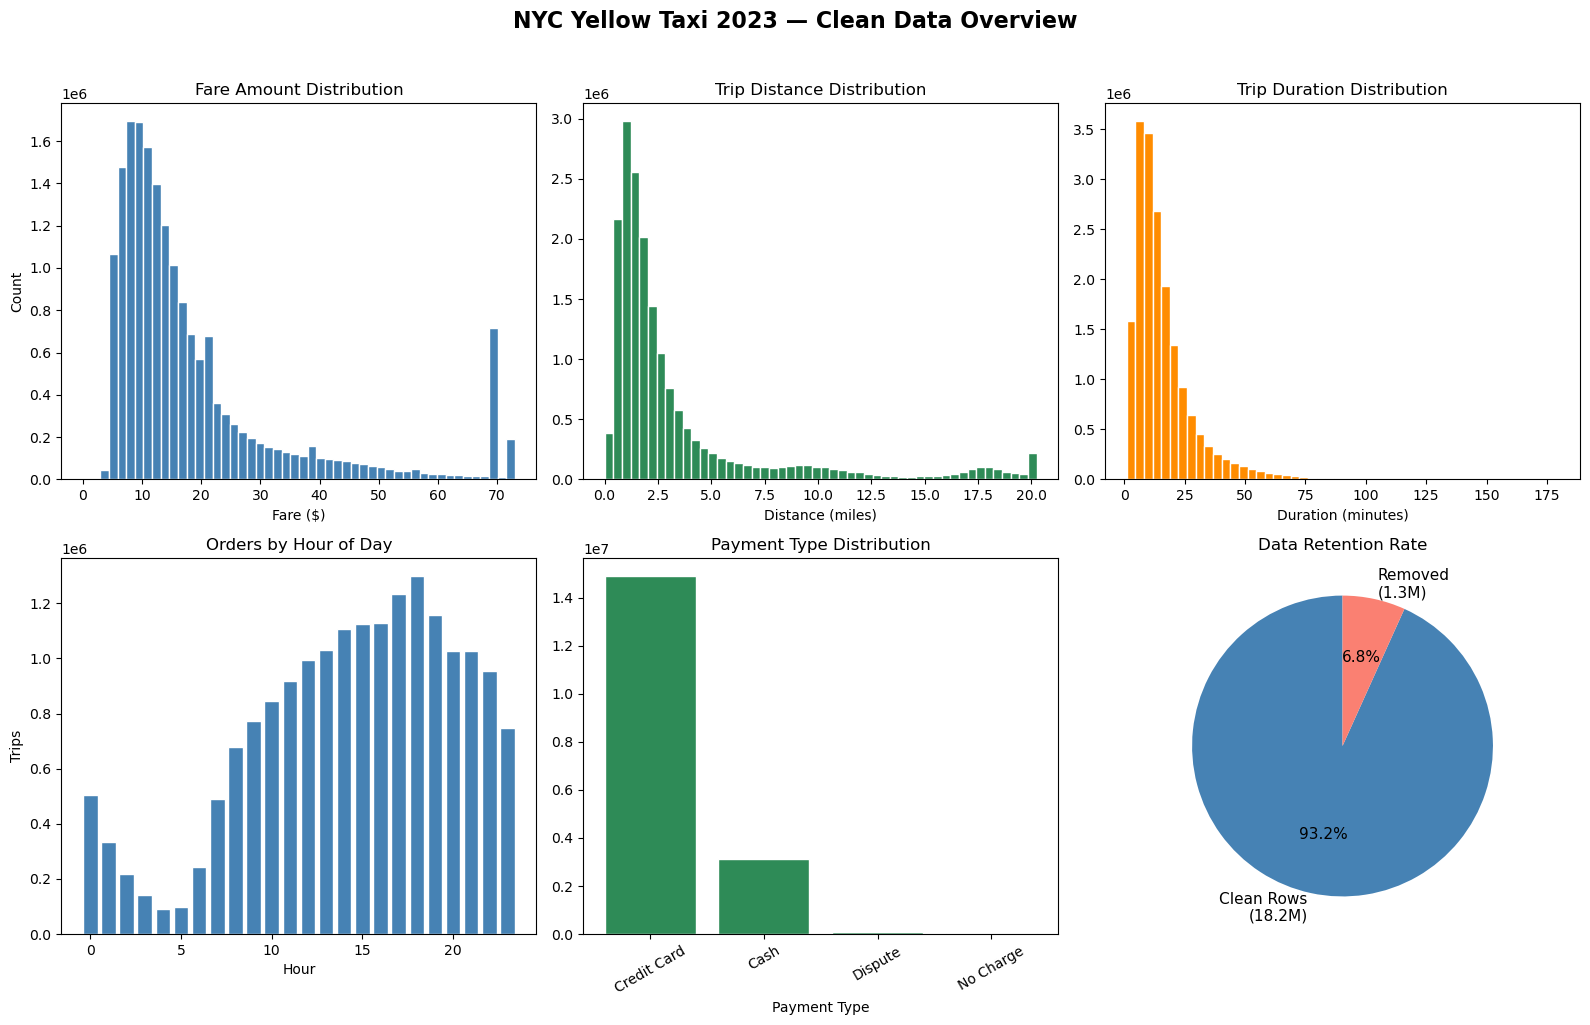

✅ Chart saved to outputs/


In [18]:
# ============================================================
# CELL 8 — Cleaning Summary Visualisation
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('NYC Yellow Taxi 2023 — Clean Data Overview', 
             fontsize=16, fontweight='bold', y=1.02)

# Plot 1 — Fare distribution
axes[0,0].hist(df['fare_amount'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Fare Amount Distribution')
axes[0,0].set_xlabel('Fare ($)')
axes[0,0].set_ylabel('Count')

# Plot 2 — Trip distance distribution
axes[0,1].hist(df['trip_distance'], bins=50, color='seagreen', edgecolor='white')
axes[0,1].set_title('Trip Distance Distribution')
axes[0,1].set_xlabel('Distance (miles)')

# Plot 3 — Trip duration distribution
axes[0,2].hist(df['trip_duration_mins'], bins=50, color='darkorange', edgecolor='white')
axes[0,2].set_title('Trip Duration Distribution')
axes[0,2].set_xlabel('Duration (minutes)')

# Plot 4 — Orders by hour
hourly = df['pickup_hour'].value_counts().sort_index()
axes[1,0].bar(hourly.index, hourly.values, color='steelblue', edgecolor='white')
axes[1,0].set_title('Orders by Hour of Day')
axes[1,0].set_xlabel('Hour')
axes[1,0].set_ylabel('Trips')

# Plot 5 — Payment type distribution
payment_counts = df['payment_type_label'].value_counts()
axes[1,1].bar(payment_counts.index, payment_counts.values, color='seagreen', edgecolor='white')
axes[1,1].set_title('Payment Type Distribution')
axes[1,1].set_xlabel('Payment Type')
axes[1,1].tick_params(axis='x', rotation=30)

# Plot 6 — Rows removed summary
labels = ['Clean Rows\n(18.2M)', 'Removed\n(1.3M)']
sizes = [18176765, 1316294]
colors = ['steelblue', 'salmon']
axes[1,2].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
              startangle=90, textprops={'fontsize': 11})
axes[1,2].set_title('Data Retention Rate')

plt.tight_layout()
plt.savefig('../outputs/nb1_cleaning_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to outputs/")

## NB1 Summary — Data Cleaning Complete

### Dataset
- **Source:** NYC Yellow Taxi Trip Records Jan–Aug 2023
- **Original rows:** 19,493,059
- **Clean rows:** 18,176,765 (93.2% retained)

### Key Cleaning Decisions
1. Removed negative/zero fares — invalid transactions
2. Removed zero-distance trips — likely cancelled or test orders
3. Removed invalid passenger counts — largest removal at 815K rows
4. Capped fare at $73 (99th percentile) — removes extreme outliers
5. Capped distance at 20.25 miles — removes airport/long-haul outliers
6. Removed trips <1 min or >180 mins — unrealistic durations

### Features Engineered
- `trip_duration_mins` — seconds converted to minutes
- `pickup_hour`, `pickup_day_of_week`, `pickup_month` — time features
- `is_weekend` — boolean flag
- `speed_mph` — distance / duration
- `tip_pct` — tip as % of fare
- `payment_type_label` — human readable payment labels

### Next Step → NB2: EDA & Visualisation